(1060, 1904, 3)

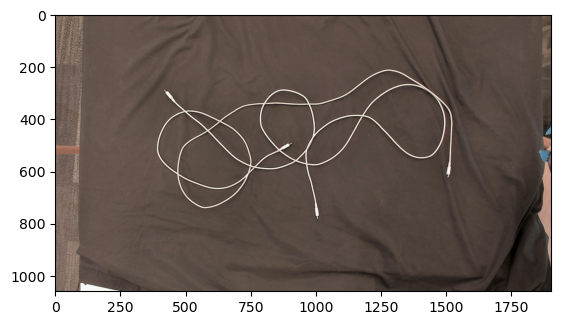

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

# im_frame2 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_only_img_depth_pairs/intensity_image2024-06-29T18:00:38.984569.png')
# im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240711-124446.png")
# im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240730-151034.png")
im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240730-152135.png")

np_frame2 = np.array(im_frame2)

# remove alpha channel
# np_frame2 = np_frame2[0:650, :, :3]
# tt_frame2 = torch.tensor(np_frame2).to(torch.uint8)
plt.imshow(np_frame2)
np_frame2.shape

(1060, 1904, 3)


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride
/home/mallika/anaconda3/envs/vsumedh-lipnew-tangential/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Endpoint detection took 2.744861125946045 seconds


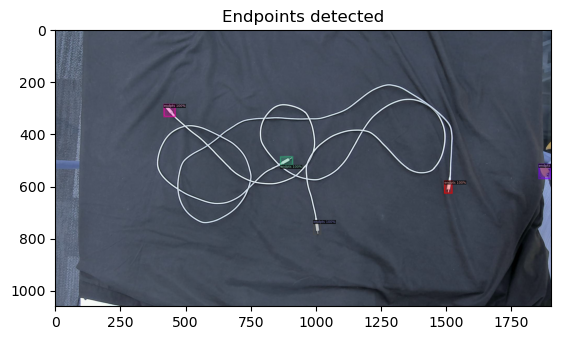

(1060, 1904, 3)
[[ 758 1006]
 [ 311  439]
 [ 604 1509]
 [ 504  888]
 [ 544 1879]]


<Figure size 640x480 with 0 Axes>

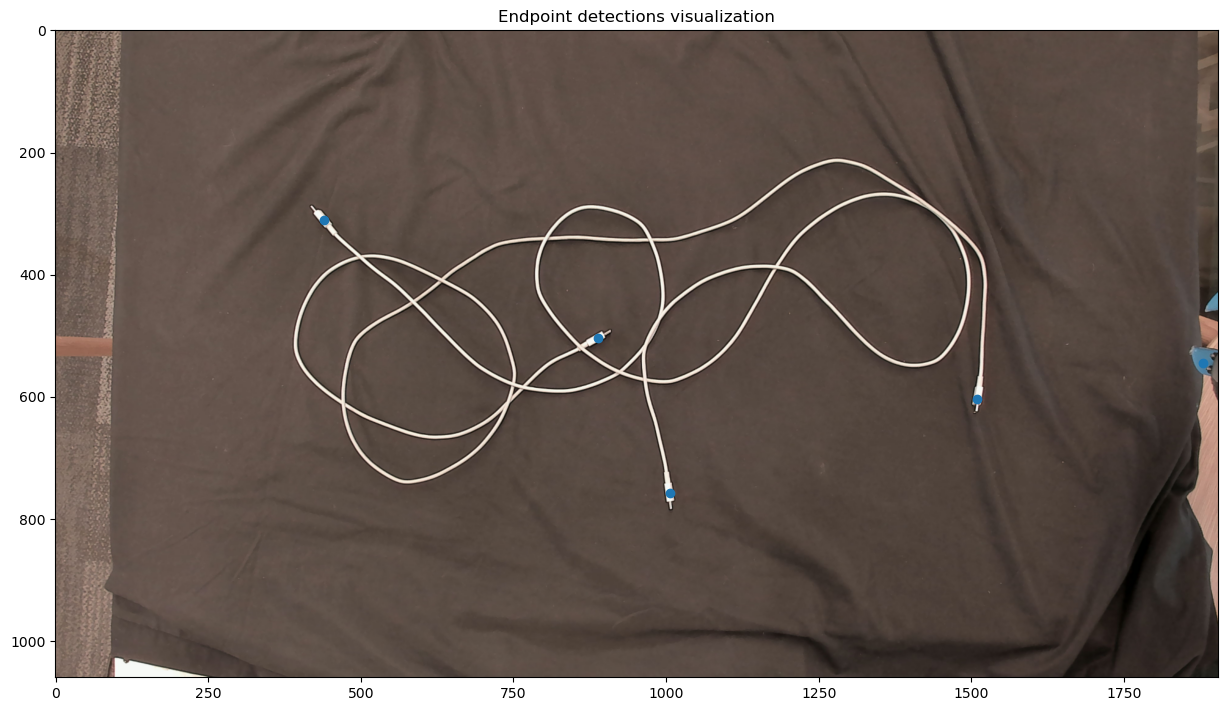

In [2]:
img = np_frame2
from decluttering.data.detectron2_repo import analysis as loop_detectron
import numpy as np 
import time

def get_endpoints(img):
    # model not used, already specified in loop_detectron
    # self.img = self.iface.take_image()
    endpoint_start = time.time()
    endpoint_boxes, out_viz = loop_detectron.predict(img, thresh=0.99, endpoints=True)
    endpoint_end = time.time()
    print("Endpoint detection took {} seconds".format(endpoint_end - endpoint_start))
    plt.clf()
    plt.imshow(out_viz)
    plt.title("Endpoints detected")
    plt.show()
    plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected.png", out_viz)
    print(out_viz.shape)
    # show_img()

    endpoints = []
    for i, box in enumerate(endpoint_boxes):
        xmin, ymin, xmax, ymax = box
        x = (xmin + xmax)/2
        y = (ymin + ymax)/2

        # print(xmin.astype(np.int32))
        # plt.clf()
        # plt.imshow(img[ymin.astype(np.int32):ymax.astype(np.int32), xmin.astype(np.int32):xmax.astype(np.int32)])
        # plt.show()
        # plt.imsave(f"/home/justinyu/multicable-decluttering/misc_images/endpoints_crop{i}.png", img[ymin.astype(np.int32):ymax.astype(np.int32), xmin.astype(np.int32):xmax.astype(np.int32)])
        # new_yx = self.closest_valid_point(self.img.color._data, self.img.depth._data, np.array([y,x]))
        # print(x)
        # print(y)
        # endpoints.append([new_yx, new_yx])
        endpoints.append([y, x])   
    endpoints = np.array(endpoints).astype(np.int32)
    print(endpoints)
    # # (n,2,2) (num endpoints, (head point, neck point), (x,y))
    # endpoints = np.array([e for e in endpoints if self.img.depth._data[e[0][0], e[0][1]] > 0])
    # self.logger.debug("Found {} true endpoints after filtering for depth".format(len(endpoints)))

    plt.clf()
    plt.figure(figsize=(15,18))
    plt.title("Endpoint detections visualization")
    plt.imshow(img)
    if len(endpoints) > 0:
        plt.scatter(endpoints[:, 1], endpoints[:, 0])
    plt.show()
    # plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected_with_clutter.png", img)
    # self.show_img()

    # endpoints = endpoints.astype(np.int32).reshape(-1, 2, 2)
    # # endpoint1 = endpoints[0][0]
    # # endpoint2 = endpoints[1][0]
    # self.endpoints = endpoints[:, 0, :] #np.array([endpoint1, endpoint2])
    return endpoints

print(img.shape)
endpts = get_endpoints(img)

/home/mallika/anaconda3/envs/vsumedh-lipnew-tangential/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Loading pretrained CLIP
Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy
Inference time:  0.06099438667297363
Number of masks before filtering torch.Size([5, 1, 1060, 1904])
Area of masks before filtering tensor([ 100680,   14176,    1735, 1901234, 1901805], device='cuda:0')
torch.Size([2, 1, 1060, 1904])


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


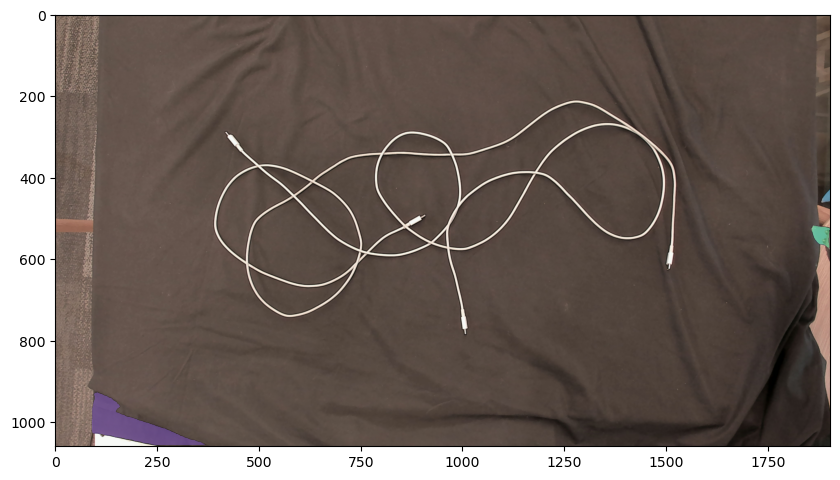

In [3]:
from decluttering.data.utils.detic_dataloader import DeticDataloader

detic = DeticDataloader()
detic.create()
detic.default_vocab()
out = detic.predict(np_frame2)
import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 17000, min_area = 500):
    """
    Filter masks by area
    """
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[(mask_areas < max_area) & (min_area < mask_areas)]
    return masks_filtered

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]

starting_block = filter_mask_by_area(out['masks'], max_area = 24000, min_area = 17000)
detic.visualize_output(np_frame2, filtered_areas, image_save_path=f"detic_masks/filtered_masks{time}.png")

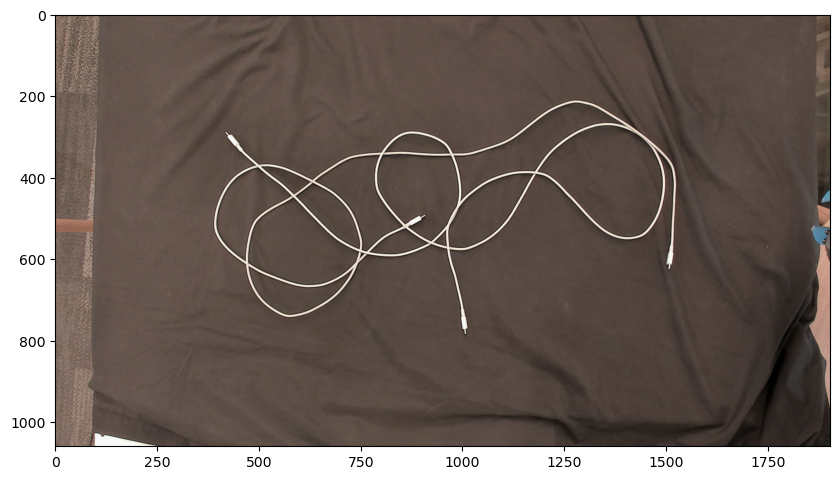

In [4]:
detic.visualize_output(np_frame2, starting_block)

In [5]:
# def combine_masks(masks):
#     """
#     Combine masks into a single mask
#     """
#     ones = torch.ones(masks[0].shape).to(masks.device)
#     combined_mask = torch.minimum(torch.sum(masks, dim = 0), ones).squeeze(0)
#     return combined_mask

# plt.imshow(combine_masks(filtered_areas).cpu().numpy())

In [6]:
# def filter_endpoint_centers(combined_mask, endpoints):
#     # Filter out endpoints that fall inside of a clutter object mask
#     # combined_mask shape is (H, W)
#     # endpoints is a list of shape (n, 2) (num endpoints, (x,y)) i.e. [[ 77 463] [279 225] [336 486] [370 352]]
#     endpoint_centers = []
#     for endpoint in endpoints:
#         y, x = endpoint
#         if combined_mask[y, x] == 0:
#             endpoint_centers.append(endpoint)
#     return endpoint_centers

# print(endpts)
# filtered_endpoint_centers = np.array(filter_endpoint_centers(combine_masks(filtered_areas), endpts))

In [7]:

# plt.clf()
# plt.figure(figsize=(15,18))
# plt.title("Filtered Endpoint detections visualization")
# plt.imshow(img)
# if len(filtered_endpoint_centers) > 0:
#     plt.scatter(filtered_endpoint_centers[:, 1], filtered_endpoint_centers[:, 0])
# plt.show()

In [8]:
from decluttering.data.tracer.analytic_tracer.simple_uncertain_trace_single import trace

def analytic_tracer(img, point, keepout_mask=None):
        # trace from endpoint on image
        path, finished_paths = trace(img, point, exact_path_len=3, viz=True, keepout_mask=keepout_mask)
        agree_point = tuple(np.array([point[0], point[1]]).astype(np.int32))
        if path is None:
            if len(finished_paths) > 0:
                min_len_path = float('inf')
                for fp in finished_paths:
                    if len(fp) < min_len_path:
                        min_len_path = len(fp)
                for i in range(min_len_path):
                    values = np.array([list(fp[i]) for fp in finished_paths])
                    x = values[:, 0]
                    y = values[:, 1]
                    x_diff = np.max(x)-np.min(x)
                    y_diff = np.max(y)-np.min(y)
                    if x_diff < 5 and y_diff < 5:
                        agree_point = values[0]
            return agree_point, True
        return path, False



[ 758 1006]


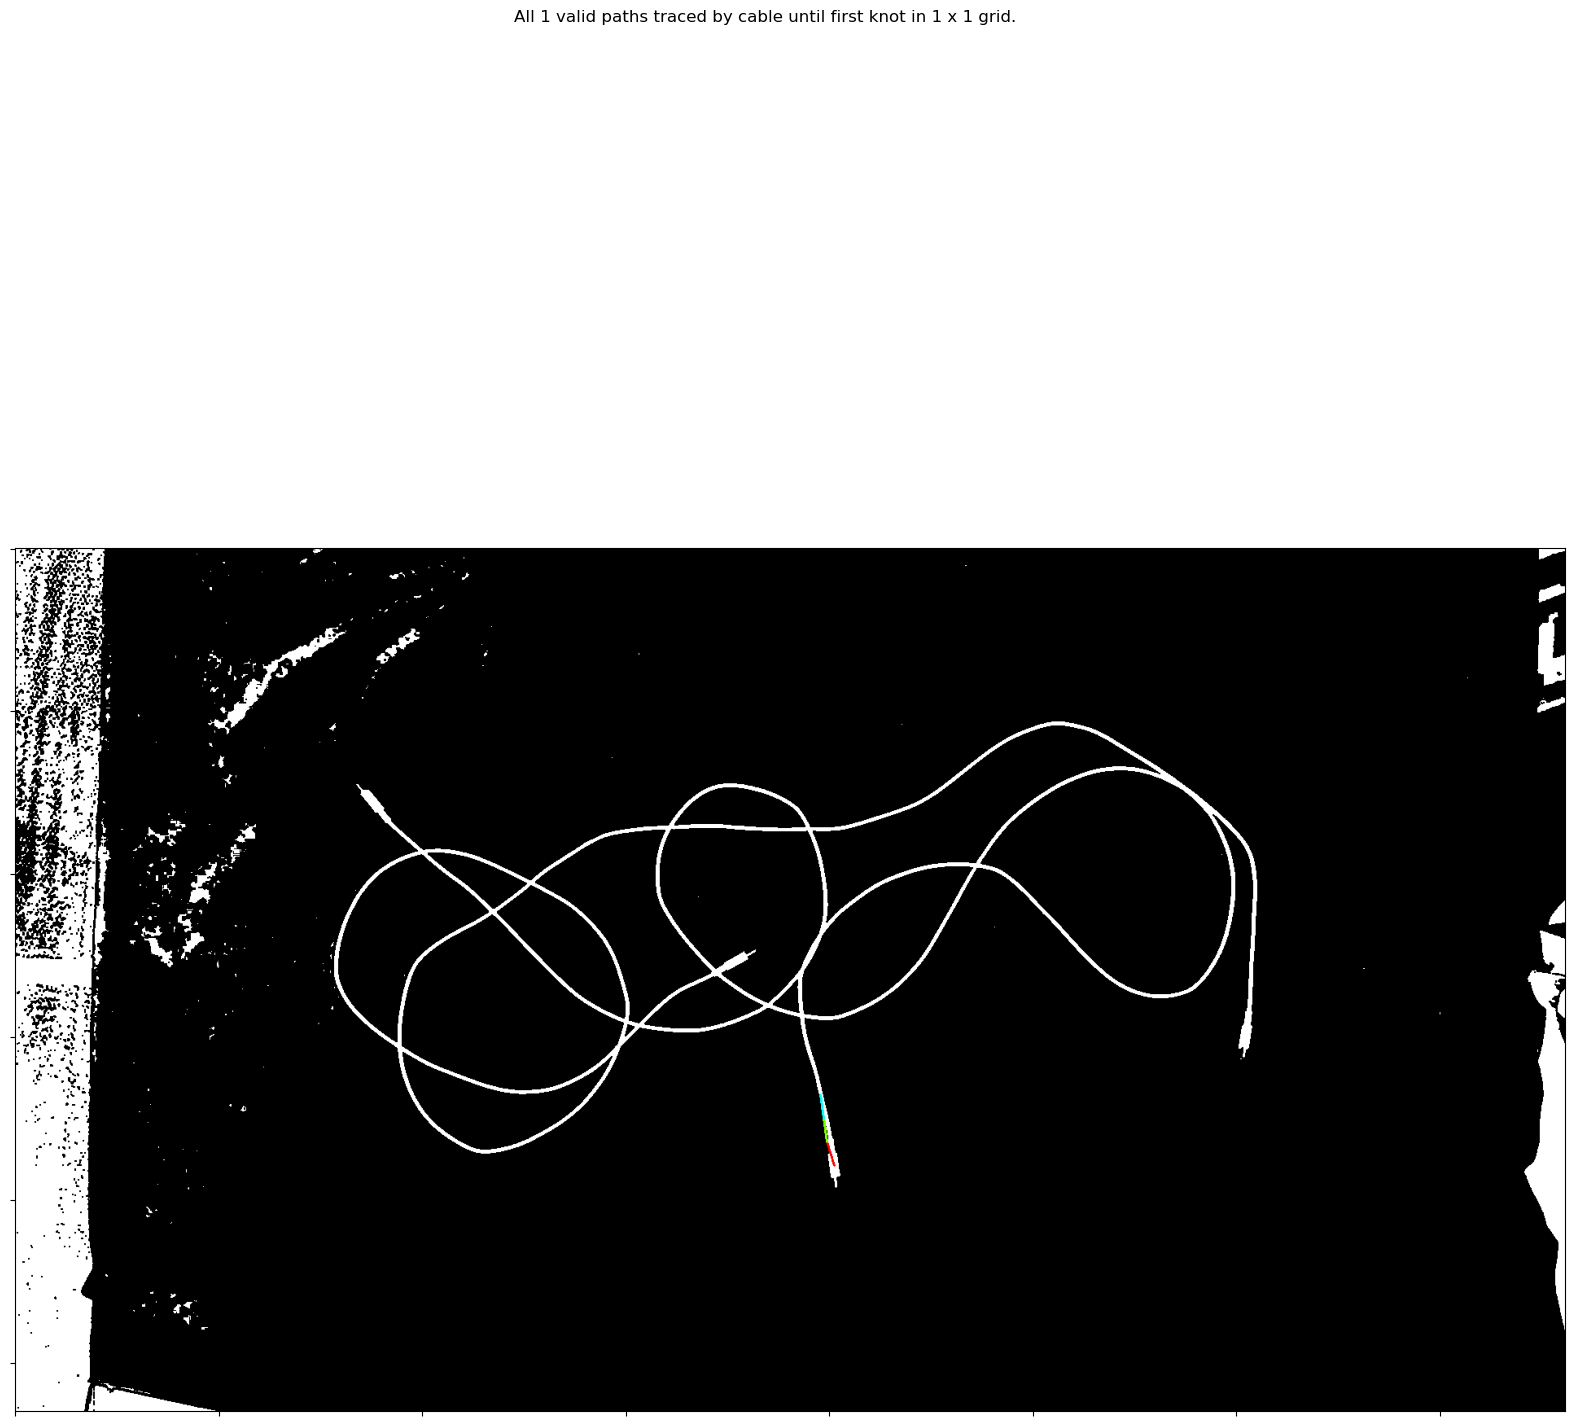

[[ 758 1006]
 [ 729  997]
 [ 700  993]
 [ 671  989]]


In [9]:
random_endpt = np.random.permutation(len(endpts))[0]

print(np.array(endpts[random_endpt]))

# print(np.array(endpts[0]))
# print(np.array(filtered_endpoint_centers[random_endpt]))

# starting_pixels = analytic_tracer(img, np.array(endpts[0]))

# keepout = starting_block.squeeze(0).squeeze(0).unsqueeze(-1).cpu().numpy()
starting_pixels = analytic_tracer(img, np.array(endpts[random_endpt]), keepout_mask=None)
print(np.asarray(starting_pixels[0]).astype(int))

Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  2.615839958190918


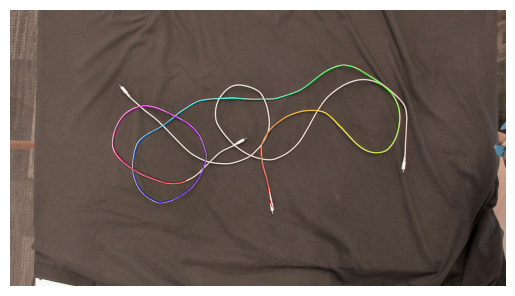

In [10]:
from decluttering.data.tracer.tusk_pipeline.tracer import Tracer
import datetime
from decluttering.data.utils.tracer_dataloader import TracerDataloader
time = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
tracer = TracerDataloader()
# print(np.asarray(starting_pixels[0]).astype(int))

# replace run_tracer_with_transform -> tracer.predict
out = tracer.predict(img, np.asarray(starting_pixels[0]).astype(int), endpoints=endpts)
# print(trace)
trace = out["trace"]
heatmaps = out["heatmaps"]

plt.imshow(tracer.tracer.visualize_path(img, np.array(trace)))
plt.axis('off')
plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_trace.png", tracer.tracer.visualize_path(img, np.array(trace)))


In [11]:

# cov_det = out["covariances"]

# cov_det_argmax = 0

# print(trace[0][cov_det_argmax])

# normalized_covs = [(cov - min(cov_det))/(max(cov_det) - min(cov_det)) for cov in cov_det]
# cov_det
# print(normalized_covs)
# print("len normalized covs = " + str(len(normalized_covs)))
# plt.imshow(tracer.tracer.visualize_path(img, np.array(trace), color=normalized_covs))
# plt.axis('off')
# plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_entropy.png", tracer.tracer.visualize_path(img, np.array(trace), color=normalized_covs))
# plt.scatter(trace[cov_det_argmax][1], trace[cov_det_argmax][0], c='b')
# plt.savefig("/home/justinyu/multicable-decluttering/decluttering/scripts/test/path_certainty_cov_det_max_labeled5.png",bbox_inches='tight',
#     pad_inches = 0)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 4.12369664e-05 5.96420032e-05 5.02304028e-05 6.66707929e-05
 9.25641871e-05 5.60098141e-02 2.84339506e-02 2.91217840e-03
 5.00179711e-04 6.07952476e-04 2.55442853e-03 3.78606200e-01
 9.30815279e-01 2.52663076e-01 1.34286061e-01 5.45444727e-01
 7.56108105e-01 2.13808790e-01 7.90119618e-02 2.45652840e-01
 1.51737240e-05 1.39274762e-05 1.60264499e-05 1.25375982e-05
 1.34940237e-05 1.43731386e-05 1.67558683e-05 1.68358129e-05
 3.08983726e-05 1.93201620e-02 2.29912787e-03 2.50543095e-03
 7.91358820e-04 2.64793431e-04 3.41088271e-05 1.69304680e-04
 1.20900928e-04 1.16661726e-03 1.21616328e-03 6.13188371e-04
 8.28149321e-04 7.58048904e-04 1.00648915e-03 1.60494936e-03
 8.18058325e-04 4.02862555e-04 1.44923571e-04 1.24036553e-04
 6.27787667e-05 3.80096899e-05 5.02391194e-05 1.57774157e-05
 2.04456883e-05 2.63124348e-05 2.40303380e-05 4.52924432e-05
 4.58811483e-05 4.25930448e-05 3.76041971e-05 1.43237325e-04
 2.42217705e-01 8.885546

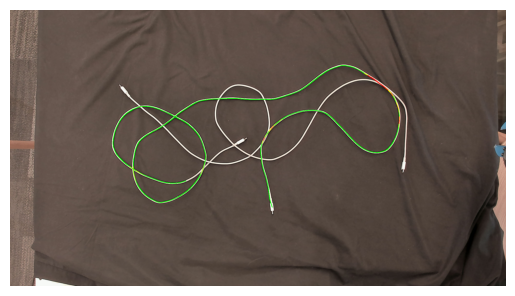

In [12]:
# Veena: heatmap for ViT
# vit_conf_path = [0, 0, 0, 0] + out["vit"]
vit_conf_path = out["vit"]
print(vit_conf_path)
# vit_conf_path = [(v - min(vit_conf_path))/(max(vit_conf_path) - min(vit_conf_path)) for v in vit_conf_path]
print(len(vit_conf_path))
# print(vit_conf_path.mean())
plt.imshow(tracer.tracer.visualize_path(img, np.array(trace), color=vit_conf_path))
plt.axis('off')
plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_vit.png", tracer.tracer.visualize_path(img, np.array(trace), color=vit_conf_path))

In [13]:
old_cov_det = trace[5]

old_cov_det_argmax = np.asarray(old_cov_det).argmax()

print(trace[0][cov_det_argmax])

old_normalized_covs = [(cov - min(old_cov_det))/(max(old_cov_det) - min(old_cov_det)) for cov in old_cov_det]

plt.imshow(tracer.visualize_path(img, np.array(trace[0]), color=old_normalized_covs))
plt.axis('off')
plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_cov_det_old.png", tracer.visualize_path(img, np.array(trace[0]), color=old_normalized_covs))
plt.scatter(trace[0][cov_det_argmax][1], trace[0][cov_det_argmax][0], c='r')
plt.savefig("/home/justinyu/multicable-decluttering/decluttering/scripts/test/path_certainty_cov_det_max_labeled5.png",bbox_inches='tight',
    pad_inches = 0)

NameError: name 'cov_det_argmax' is not defined

In [ ]:
cable_density = trace[4]
print(np.asarray(cable_density).max())
normalized_cable_density = [(cd - min(cable_density))/(max(cable_density) - min(cable_density)) for cd in cable_density]

plt.imshow(tracer.visualize_path(img, np.array(trace[0]), color=normalized_cable_density))
plt.axis('off')
plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_density.png", tracer.visualize_path(img, np.array(trace[0]), color=normalized_cable_density))


In [ ]:
# print(len(trace[3]))
# print(len(trace[0]))
# print(len(trace[1]))
# print(len(trace[2]))
# print(trace[0])
# print(cov_det_argmax)
# print(cov_det[cov_det_argmax])
# max_uncertain_idx = cov_det_argmax -len(starting_pixels[0])

offset = -7

# print(cov_det[cov_det_argmax+offset])
plt.imshow(trace[2][cov_det_argmax+offset-len(starting_pixels[0])])
plt.imshow(trace[1][cov_det_argmax+offset-len(starting_pixels[0])], alpha=0.5)
plt.savefig(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/heatmap_{offset}.png",bbox_inches='tight')

IndexError: tuple index out of range

In [ ]:
model_output = trace[1][cov_det_argmax+offset-len(starting_pixels[0])]
def compute_weighted_covariance_matrix(data):
    """
    Computes the weighted covariance matrix of a 2D numpy array.
    
    Parameters:
    data (np.ndarray): A 2D numpy array of scalar values representing weighted pixels.
    
    Returns:
    np.ndarray: A 2x2 covariance matrix.
    """
    # Get the shape of the array
    rows, cols = data.shape
    
    # Create a grid of coordinates
    y, x = np.meshgrid(np.arange(rows), np.arange(cols), indexing='ij')
    
    # Flatten the arrays
    x_flat = x.flatten()
    y_flat = y.flatten()
    data_flat = data.flatten()
    
    # Compute the weighted mean of the coordinates
    total_weight = np.sum(data_flat)
    mean_x = np.sum(x_flat * data_flat) / total_weight
    mean_y = np.sum(y_flat * data_flat) / total_weight
    
    # Center the coordinates by subtracting the weighted mean
    x_centered = x_flat - mean_x
    y_centered = y_flat - mean_y
    
    # Compute the weighted covariance matrix
    cov_xx = np.sum(data_flat * x_centered * x_centered) / total_weight
    cov_xy = np.sum(data_flat * x_centered * y_centered) / total_weight
    cov_yy = np.sum(data_flat * y_centered * y_centered) / total_weight
    
    covariance_matrix = np.array([[cov_xx, cov_xy], [cov_xy, cov_yy]])
    
    return covariance_matrix, mean_x, mean_y

cov_matrix, mean_x, mean_y = compute_weighted_covariance_matrix(model_output)
print(cov_matrix)
print(mean_x)
print(mean_y)

cov_det = np.linalg.det(cov_matrix)
print(cov_det)


[[ 0.65077088 -0.21816514]
 [-0.21816514  8.67594827]]
31.04263955176619
46.59891671668006
5.598458480685106


3.699122710679731


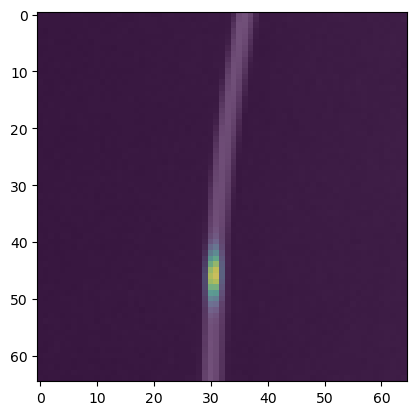

In [ ]:
import scipy.stats

def plot_cov_ellipse_colormap(mean=[0,0], cov=[[1,0],[0,1]], img = None):
    side = np.linspace(0, 65, 65)
    X,Y = np.meshgrid(side,side)

    pos = np.empty(X.shape + (2,))
    pos[:, :, 0] = X;
    pos[:, :, 1] = Y
    # plt.axes(xticks=[], yticks=[], frameon=True)

    # plt.gca().invert_yaxis()
    # cov.transpose(1,0)
    rv = scipy.stats.multivariate_normal((mean[0],mean[1]), cov)
    print(rv.entropy())
    if img is not None:
        plt.imshow(img)
    plt.gca().grid(b=False)
    plt.gca().imshow(rv.pdf(pos), cmap='viridis', alpha=0.5)
    plt.show()

# print(cov_matrix)
# print(np.flip(cov_matrix).T)
plot_cov_ellipse_colormap(mean=[mean_x,mean_y], cov = cov_matrix, img = trace[2][cov_det_argmax+offset-len(starting_pixels[0])])